### Dependencies

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

### Loading dataset

In [3]:
df = pd.read_csv("Train.csv")

print(df.head())
print(df.info())

   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233            

### Checking for missing values

In [4]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

### Checking if the dataset is skewed or balanced

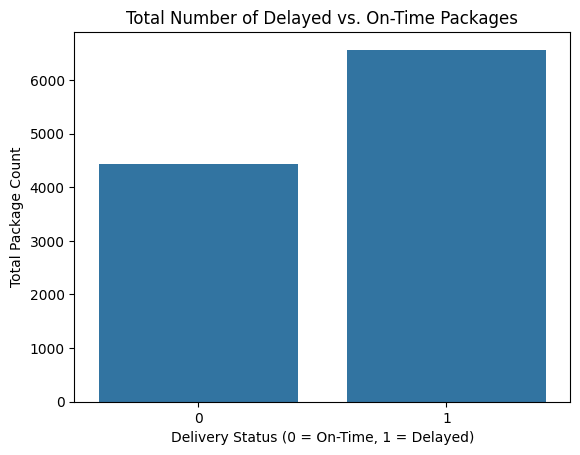

In [5]:
sns.countplot(data=df, x="Reached.on.Time_Y.N")
plt.title("Total Number of Delayed vs. On-Time Packages")
plt.xlabel("Delivery Status (0 = On-Time, 1 = Delayed)")
plt.ylabel("Total Package Count")
plt.show()

### Identifying correlations

#### 1. Categorical Data:

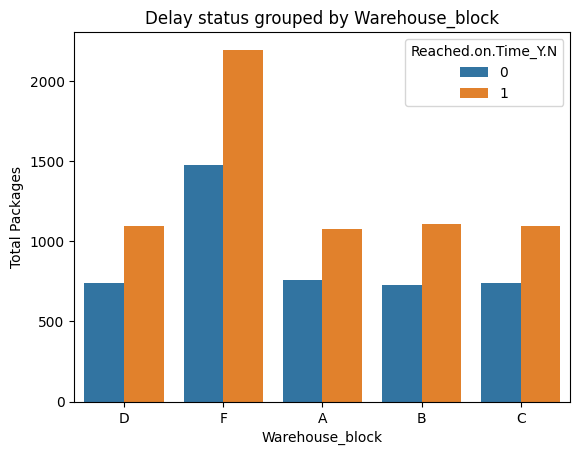

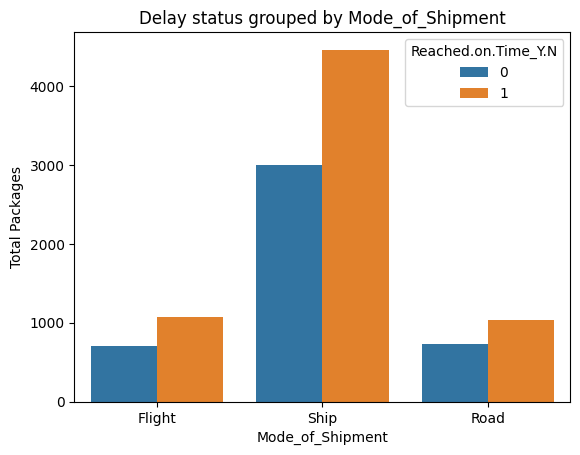

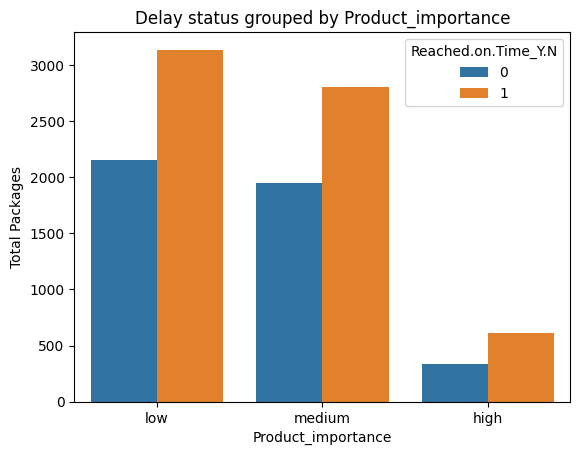

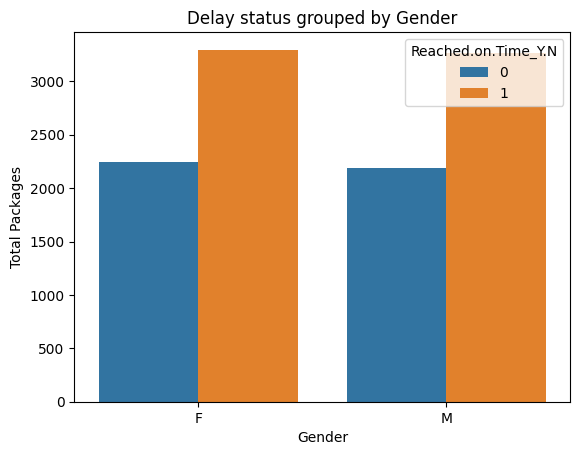

In [6]:
catg_cols = df.select_dtypes(include=['str']).columns

for col in catg_cols:
    sns.countplot(data=df, x=col, hue='Reached.on.Time_Y.N')
    plt.title(f"Delay status grouped by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Packages")
    plt.show()

In the above barplots we can see that categorical data overall is not giving us a lot of info so we move to numerical data for further insights.

#### 2. Numerical Data:

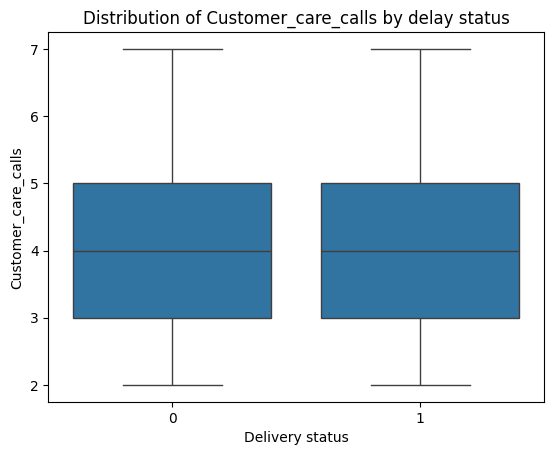

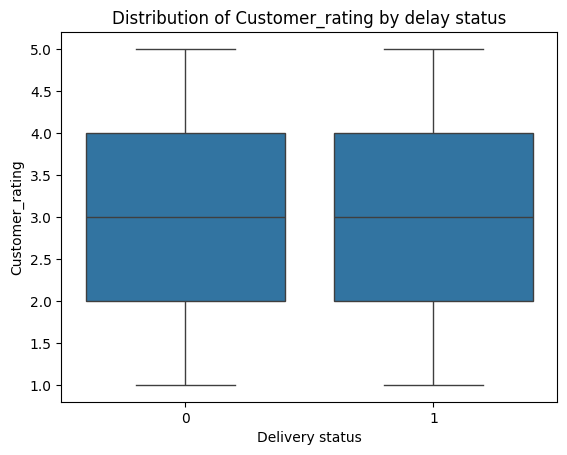

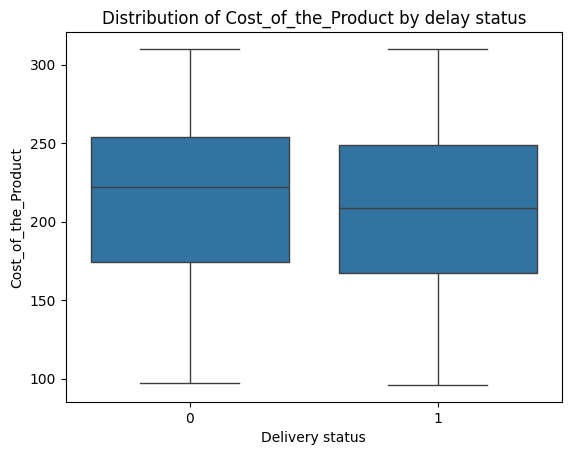

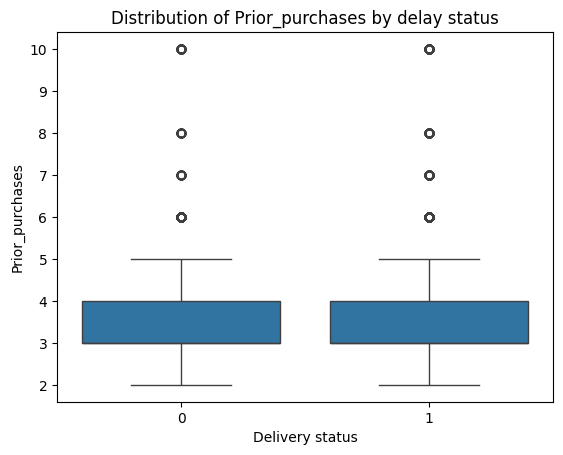

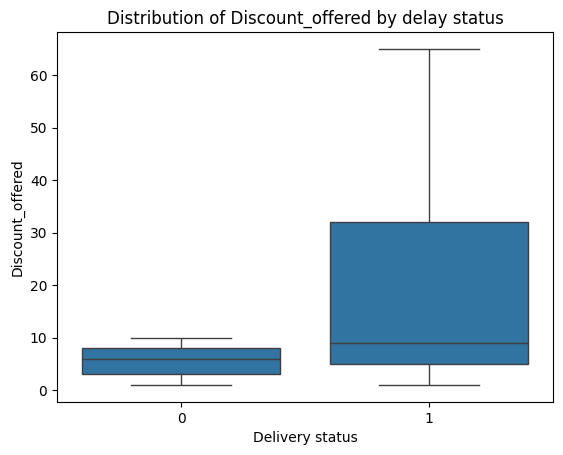

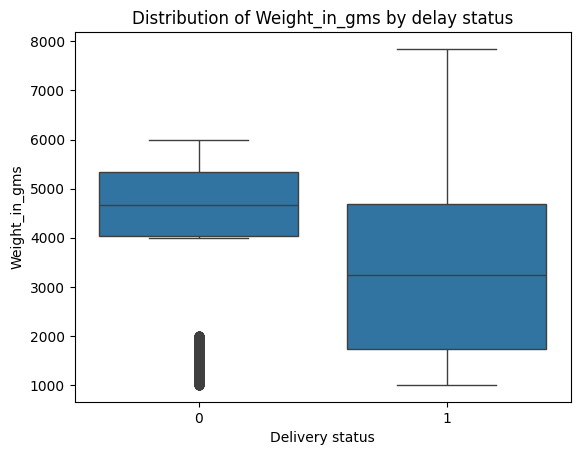

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cols_plot = [col for col in num_cols if col not in ['ID','Reached.on.Time_Y.N']]

for col in cols_plot:
    sns.boxplot(data=df, x='Reached.on.Time_Y.N', y=col)
    plt.title(f"Distribution of {col} by delay status")
    plt.xlabel("Delivery status")
    plt.ylabel(col)
    plt.show()

In the above boxplots we apply the overelapping test. Basically, we have to see in which plot are the two plots at completely different heights or in the other words completely different from each other.

We can see that the features "Discount_offered" and "Weight_in_gms" have unique box plots they show compltely different plottings between their "0" and "1" labels. So, we can make a conclusion that these two features have a strong relation with the target label.

### Removing Useless Data

In [8]:
df = df.drop(["ID", "Customer_rating", "Prior_purchases", "Customer_care_calls"], axis=1)
print(df.columns)

Index(['Warehouse_block', 'Mode_of_Shipment', 'Cost_of_the_Product',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='str')


In [9]:
df = df.drop(["Gender"], axis=1)
print(df.columns)

Index(['Warehouse_block', 'Mode_of_Shipment', 'Cost_of_the_Product',
       'Product_importance', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='str')


Here we removed the columns "ID", "Customer_rating", "Prior_purchases", "Customer_care_calls" and "Gender" have been dropped since they did not have much influence on the target label.

### One-Hot Encoding

In [10]:
df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'], drop_first=True)
print(df.columns)

Index(['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Warehouse_block_B', 'Warehouse_block_C',
       'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road',
       'Mode_of_Shipment_Ship', 'Product_importance_low',
       'Product_importance_medium'],
      dtype='str')


Here we converted our remaining text-based features into a numerical format (1s and 0s) using one-hot encoding, as machine learning models require numerical inputs. We also dropped the first category of each feature to prevent redundant data and avoid confusing the algorithm.

### Correlation Heatmap

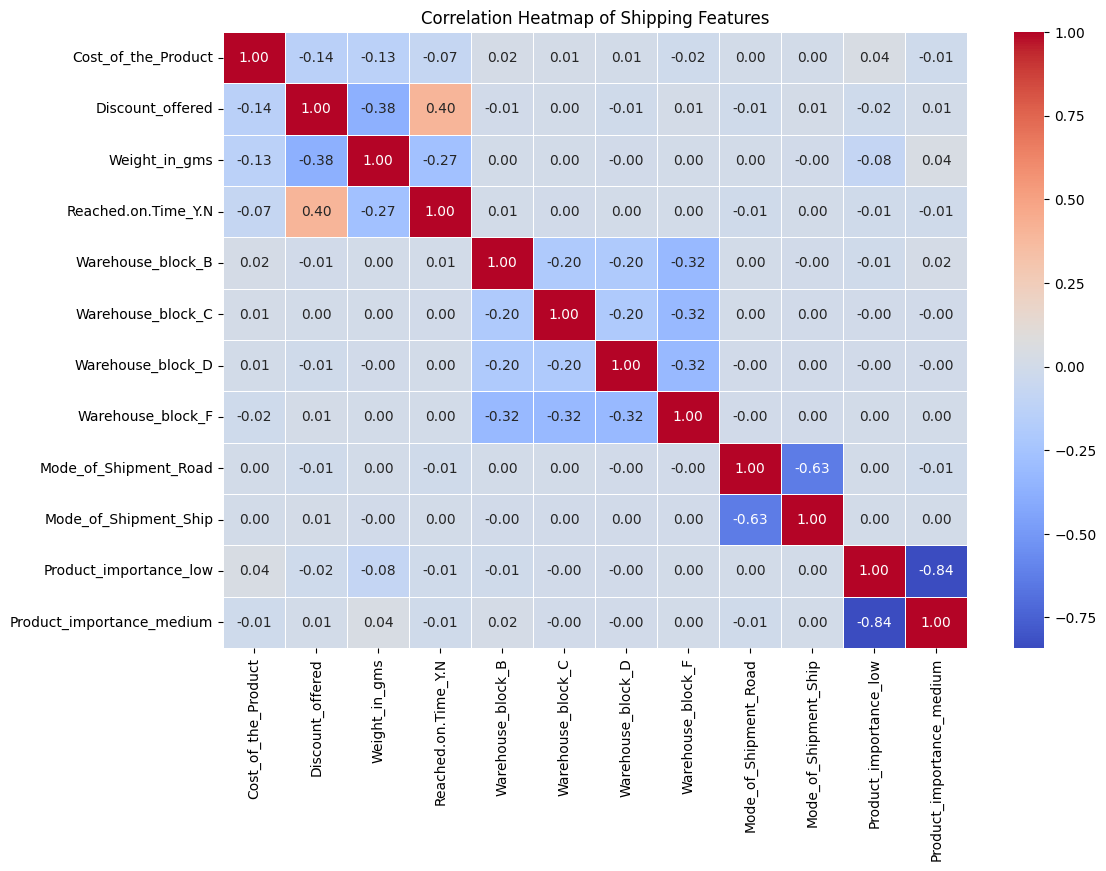

In [11]:
corr_m = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_m, annot=True, fmt=".2f", linewidths=0.5, cmap="coolwarm")
plt.title("Correlation Heatmap of Shipping Features")
plt.show()

This correlation heatmap shows us how much a feature is influencing the target label. It calculates the Pearson Correlation Coefficient(PCC) of all the features. Above in the fourth row from top we can see our target label and it's PCC with all the features or we can see the fourth column from left.

### Splitting Testing and Training Sets

In [12]:
y = df["Reached.on.Time_Y.N"]
x = df.drop(["Reached.on.Time_Y.N"], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

Here we split our dataset into 80-20 where 80% is our training data and 20% is testing data.

### Feature Scaling

In [13]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

print(f"Original x_train shape: {x_train.shape}")
print(f"Scaled x_train_scaled shape: {x_train_scaled.shape}")

Original x_train shape: (8799, 11)
Scaled x_train_scaled shape: (8799, 11)


Algorithms like K-Nearest Neighbors calculate mathematical distances and will unfairly prioritize features with massive numbers. By using StandardScaler to compress all features to a similar scale, we prevent large values like Weight from dominating the math and ensure every column is treated equally by the model.

### Model Training

In this section we are going to initialize and train our three models.

#### 1. Logistic Regression

In [14]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(x_train_scaled, y_train)
y_pred_log = log_model.predict(x_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Baseline Accuracy: {log_accuracy * 100:.2f}%")

Logistic Regression Baseline Accuracy: 62.91%


Here we trained out model with the dataset. No tweaks were made to the model here and we got a baseline accuracy of 62.91%

##### Regularization

Here we used regularization to introduce penalty system in our logistic regression model. This will penalize the model when it chooses big values for weights. It does this by squaring the error in our cost function resulting in a high penalty. To reduce the penalty the model will have to choose small values for weights.

In [15]:
warnings.filterwarnings('ignore')

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Starting grid search...")
grid_search.fit(x_train_scaled, y_train)

print("---GRID SEARCH RESULTS---")
print(f"The best parameters found: {grid_search.best_params_}")
print(f"The best training (CV) score: {grid_search.best_score_*100:.2f}%")

best_log_model = grid_search.best_estimator_

y_pred_optimized = best_log_model.predict(x_test_scaled)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)

print(f"Final optimized test accuracy: {optimized_accuracy*100:.2f}%")

Starting grid search...


---GRID SEARCH RESULTS---
The best parameters found: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
The best training (CV) score: 64.06%
Final optimized test accuracy: 64.09%


We automate the process of finding the absolute best mathematical parameters for our Logistic Regression model using a technique called Grid Search with Cross-Validation. Instead of manually guessing the optimal settings, we define a "grid" of possible hyperparameter combinations, specifically testing various levels of the complexity parameter C alongside both L1(Eliminating Weights) and L2(Shrinking Weights) penalty types. The algorithm systematically builds and evaluates a separate model for every single combination in the grid. To ensure the results are statistically reliable and not just a lucky fluke on a specific cut of data, it uses 5-fold cross validation meaning it repeatedly slices the training data into different testing phases and averages the accuracy. Once the engine identifies the single best combination that maximizes accuracy while preventing overfitting, it automatically applies that winning configuration to our completely unseen test data, providing us with a final, unbiased performance metric.

After performing regularization on our model we got an accuracy of 64.09% which is a 1.18% increase from before.

##### Polynomial Regression

While traditional Logistic Regression is highly efficient, it is strictly limited to drawing rigid, linear decision boundaries. Polynomial regression overcomes this "linear ceiling" by mathematically capturing non linear relationships within the data. Instead of changing the underlying algorithm, this technique transforms the dataset itself by creating new, higher order features such as squaring existing variables or multiplying variables together to find interaction effects. By feeding these mathematically curved inputs into a linear model, the resulting decision boundary is allowed to gracefully bend and wrap around complex data patterns that a simple straight line could never accurately separate.

In [16]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

print(f"Original number of features: {x_train_scaled.shape[1]}")
print(f"New polynomial features: {x_train_poly.shape[1]}")

print("\nStarting polynomial grid search...")

poly_param_grid = {
    'C' : [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

poly_grid = GridSearchCV(LogisticRegression(random_state=42), poly_param_grid, cv=5, scoring='accuracy', n_jobs=1)
poly_grid.fit(x_train_poly, y_train)

best_poly_model = poly_grid.best_estimator_
y_pred_poly = best_poly_model.predict(x_test_poly)
poly_accuracy = accuracy_score(y_test, y_pred_poly)

print("\n---POLYNOMIAL RESULTS---")
print(f"Best parameters: {poly_grid.best_params_}")
print(f"Final polynomial test accuracy: {poly_accuracy*100:.2f}%")

Original number of features: 11
New polynomial features: 77

Starting polynomial grid search...

---POLYNOMIAL RESULTS---
Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Final polynomial test accuracy: 65.41%


In this code, we use PolynomialFeatures to mathematically upgrade our dataset by squaring existing variables and creating interaction terms, expanding our inputs from 11 to 77 features. By feeding this curved data into our model, we allow its previously straight decision boundary to smoothly bend around complex patterns. When we run our Grid Search on this massive new dataset, the influx of noise causes the algorithm's optimal strategy to automatically shift to an L1 (Lasso) penalty. This L1 penalty acts as a ruthless deleter, crushing the weights of the useless polynomial columns to exactly zero and keeping only the essential mathematical curves. This helps us in achieving a higher test accuracy and proving that the underlying logic of the shipping delays is non-linear.

The final accuracy of our logistic regression model is 65.41% which is a 1.32% increase from before. Any further tweaks in the model will only make small increases which would be even less than 1% which would only waste time in making those tweaks so such small results. Hence, our final accuracy is 65.41%.

#### 2. K-Nearest Neighbor

In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred_knn = knn_model.predict(x_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"K-Nearest Neigbours Accuracy: {knn_accuracy * 100:.2f}%")

K-Nearest Neigbours Accuracy: 65.05%


##### Calculating better value of k

We have two methods for calculating the best value for k first is by taking square root of the number of rows from our dataset and second is trial and error. In code k is is our parameter n_neighbors. Here we will use first method which is taking square root of the number of rows:

In [18]:
x_train_scaled.shape

(8799, 11)

In [19]:
k = np.sqrt(8799)
k

np.float64(93.80298502713013)

Now we set n_neighbors equal to 93 which is our value of k.

In [20]:
k_knn_model = KNeighborsClassifier(n_neighbors=93)
k_knn_model.fit(x_train_scaled, y_train)
y_pred_k_knn = k_knn_model.predict(x_test_scaled)
k_knn_accuracy = accuracy_score(y_test, y_pred_k_knn)

print(f"K-Nearest Neigbours Accuracy: {k_knn_accuracy * 100:.2f}%")

K-Nearest Neigbours Accuracy: 66.64%


Our new accuracy is 66.64% which is a 1.59% increase from before.

Now we try our second method which is trial and error method:

In [21]:
accuracy = []

for i in range(1,100):
    knn_k_model = KNeighborsClassifier(n_neighbors=i)
    knn_k_model.fit(x_train_scaled, y_train)
    y_pred_knn_k = knn_k_model.predict(x_test_scaled)
    accuracy.append(accuracy_score(y_test, y_pred_knn_k))

accuracy    

[0.6395454545454545,
 0.649090909090909,
 0.6513636363636364,
 0.6659090909090909,
 0.6504545454545455,
 0.6545454545454545,
 0.6454545454545455,
 0.6436363636363637,
 0.649090909090909,
 0.6568181818181819,
 0.6413636363636364,
 0.6536363636363637,
 0.6527272727272727,
 0.6622727272727272,
 0.6563636363636364,
 0.6645454545454546,
 0.6531818181818182,
 0.6554545454545454,
 0.6572727272727272,
 0.6545454545454545,
 0.6522727272727272,
 0.6572727272727272,
 0.6522727272727272,
 0.655,
 0.649090909090909,
 0.6536363636363637,
 0.6495454545454545,
 0.6477272727272727,
 0.6495454545454545,
 0.645,
 0.6468181818181818,
 0.6518181818181819,
 0.6545454545454545,
 0.6531818181818182,
 0.6563636363636364,
 0.6527272727272727,
 0.6522727272727272,
 0.6554545454545454,
 0.6522727272727272,
 0.6563636363636364,
 0.6509090909090909,
 0.6540909090909091,
 0.6495454545454545,
 0.6513636363636364,
 0.6572727272727272,
 0.6577272727272727,
 0.6536363636363637,
 0.6590909090909091,
 0.6595454545454545,


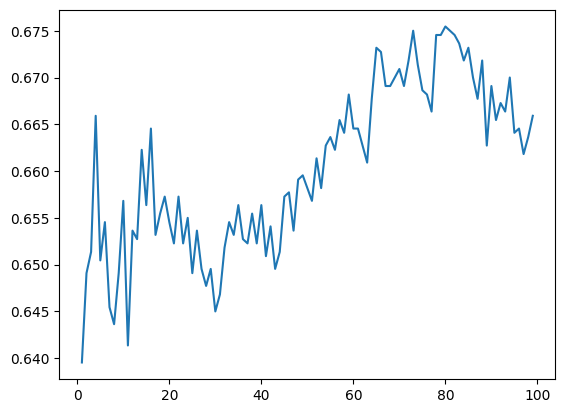

In [22]:
plt.plot(range(1,100), accuracy)

In [23]:
knn_k_model = KNeighborsClassifier(n_neighbors=79)
knn_k_model.fit(x_train_scaled, y_train)
y_pred_knn_k = knn_k_model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred_knn_k)

print(f"K-Nearest Neigbours Accuracy: {accuracy * 100:.2f}%")

K-Nearest Neigbours Accuracy: 67.45%


Now from the trail and error approach of second method we identified another better value for k which is 79. From this value of k we get an accuarcy of 67.45%.

To optimize our K-Nearest Neighbors model, we utilize a technique called Grid Search Cross Validation to systematically test multiple hyperparameter combinations and find the mathematical ceiling of our algorithm. First, we define a parameter grid testing various 'K' values around our established baseline, along with different voting weights (uniform vs. distance-based) and distance calculation metrics (Euclidean vs. Manhattan). We then initialize the GridSearchCV algorithm, configuring it to perform 5-fold cross-validation (cv=5) to ensure our accuracy scores are robust and not skewed by a lucky train test split. Finally, we fit this grid to our scaled training data, forcing the computer to evaluate every single parameter combination and output the absolute best configuration and its resulting training accuracy.

In [24]:
knn_params = {
    'n_neighbors': [75, 85, 93, 105, 115, 125],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(x_train_scaled, y_train)

print("Best K-NN Parameters:", knn_grid.best_params_)
print(f"Best Training Accuracy: {knn_grid.best_score_ * 100:.2f}%")

Best K-NN Parameters: {'metric': 'manhattan', 'n_neighbors': 125, 'weights': 'distance'}
Best Training Accuracy: 65.52%


Here we evaluate the real-world performance of our newly optimized K-NN model on test data. We instruct our trained knn_grid—which automatically utilizes the absolute best hyperparameter combination it discovered during the training phase to generate predictions on our scaled test set (x_test_scaled). We then calculate our true accuracy by comparing these newly generated predictions against the actual ground truth labels (y_test). 

In [25]:
y_pred_grid = knn_grid.predict(x_test_scaled)
grid_test_accuracy = accuracy_score(y_test, y_pred_grid)

print(f"Optimized Test Accuracy: {grid_test_accuracy * 100:.2f}%")

Optimized Test Accuracy: 66.82%


From this we get an accuracy of 66.82% which is less than the one we got before which was 67.45%. So, the final accuracy for our K-Nearest Neighbor model is 67.45% which is better than accuracy we got for logistic regression. So, far this tell us than KNN is a better model for our dataset than logistic regression.

#### 3. Decision Tree

In [26]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(x_train, y_train)
y_pred_tree = tree_model.predict(x_test)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Decision Tree Baseline Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Baseline Accuracy: 65.09%


To systematically tune our Decision Tree and prevent it from wildly overfitting the training data, we define a targeted grid of hyperparameters (dt_params). This grid tests different mathematical purity metrics (criterion), strict depth limits (max_depth), and minimum bucket sizes (min_samples_split). We feed this configuration into GridSearchCV, enforcing 5-fold cross validation (cv=5) to ensure reliable scoring. Once the grid is fitted to our training data and the absolute optimal tree architecture is discovered, we deploy that winning model to generate predictions on our unseen test data (x_test_scaled). Finally, we calculate and print the true test accuracy to officially lock in the final performance of our optimized Decision Tree.

In [27]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None], 
    'min_samples_split': [2, 10, 20, 50] 
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(x_train_scaled, y_train)
y_pred_dt = dt_grid.predict(x_test_scaled)
final_dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print(f"Optimized Test Accuracy: {final_dt_accuracy * 100:.2f}%")

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Optimized Test Accuracy: 68.32%


We got an accuracy of 68.32% which is a 3.23% increase form our baseline accuracy.

Now we execute a refined, micro-targeted Grid Search to squeeze the absolute maximum performance out of our Decision Tree. Having identified 'entropy' as the superior mathematical criterion from our initial tests, we lock it in and shift our focus entirely to structural constraints that prevent overfitting. We define a narrower search space of shallower tree depths (max_depth) and introduce a strict new regularization parameter, min_samples_leaf. This parameter forces the algorithm to ensure a minimum number of data points exist in every final decision bucket, effectively pruning away noisy, hyper-specific branches that only memorize outliers. We feed this updated configuration back into GridSearchCV with 5-fold cross validation, train it on our scaled data, and immediately evaluate the optimal model against our unseen test set to secure our finalized accuracy score.

In [28]:
dt_params_refined = {
    'criterion': ['entropy'], 
    'max_depth': [2, 3, 4, 5, 6, 7], 
    'min_samples_split': [2, 3, 4, 5], 
    'min_samples_leaf': [1, 2, 5] 
}

dt_grid_refined = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params_refined, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_refined.fit(x_train_scaled, y_train)
y_pred_dt_refined = dt_grid_refined.predict(x_test_scaled)
final_dt_refined_accuracy = accuracy_score(y_test, y_pred_dt_refined)

print("Refined Decision Tree Parameters:", dt_grid_refined.best_params_)
print(f"Final Test Accuracy: {final_dt_refined_accuracy * 100:.2f}%")

Refined Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Final Test Accuracy: 68.64%


The increase this time was not much but still there was a slight increase in the accuracy. Now our final accuracy is 68.64% which more than the final accuracies of logistic regression and KNN used on our dataset. So, we can say that decision tree is the best model for our dataset.